In [1]:
# The purpose of this project is to:
# show habitable area of 5 different cases ranging from e=0.0167 to e=0.4 for constant zero obliquity

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [2]:
# define eccentricity range

e_range =['e0','e01','e02','e03','e04']

# define path 

data_dir_file = []

for i in range(len(e_range)):
    data_dir_file.append('/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.'+ e_range[i]+'_obl0_branch.001/atm/hist/')

# define specific path

Path_TS        = []

for i in range(len(data_dir_file)):
    
    Path_TS.append(data_dir_file[i]+'TS_'+ e_range[i] +'_obl0_merge.nc')


# Import data

TS_obl0       =[]

for i in range(len(e_range)):
    TS_obl0.append(xr.open_mfdataset(Path_TS[i]))


In [3]:
File_h0 = "/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.e04_obl0.001/atm/hist/b.e21.BWma1850.f19_g17.e04_obl0.001.cam.h0.0001-03.nc" #file name

DataSet_h0 = xr.open_dataset(File_h0) 

gw = DataSet_h0.gw

weight_factor2 = gw 

# IMPORT DATA


TS_liquid_e04 = TS_obl0[4].TS.where((TS_obl0[4].TS > 273) & (TS_obl0[4].TS < 373))

TS_liquid_e03 = TS_obl0[3].TS.where((TS_obl0[3].TS > 273) & (TS_obl0[3].TS < 373))

TS_liquid_e02 = TS_obl0[2].TS.where((TS_obl0[2].TS > 273) & (TS_obl0[2].TS < 373))

TS_liquid_e01 = TS_obl0[1].TS.where((TS_obl0[1].TS > 273) & (TS_obl0[1].TS < 373))

TS_liquid_e0  = TS_obl0[0].TS.where((TS_obl0[0].TS > 273) & (TS_obl0[0].TS < 373))

pre_area_tool =[]

area_tool =[ [] for _ in range(len(TS_liquid_e04)) ]

area_total_tool =[]

TS_tool       = TS_obl0[4].TS


# TOTAL GRID COUNT
for i in range(len(TS_tool.time)): 
    pre_area_tool.append(np.logical_not(np.isnan(TS_tool.isel(time=i))).astype(int))

for i in range(len(pre_area_tool)):
    area_tool[i].append(pre_area_tool[i]*weight_factor2)

for i in range(len(area_tool)):
    area_total_tool.append(np.sum(area_tool[i]))
    
total_scaled_grid= area_total_tool[0]
    
## HabFrac()

def HabFrac(DS):
    
    Habfrac=[]
    
    for i in range(len(DS.time)):
        Habfrac.append(np.sum(np.logical_not(np.isnan(DS.isel(time=i))).astype(int)
                              *weight_factor2)/total_scaled_grid)
    
    return Habfrac



    

In [4]:
hab_frac_e04=np.array(HabFrac(TS_liquid_e04)).tolist()
hab_frac_e03=np.array(HabFrac(TS_liquid_e03)).tolist()
hab_frac_e02=np.array(HabFrac(TS_liquid_e02)).tolist()
hab_frac_e01=np.array(HabFrac(TS_liquid_e01)).tolist()
hab_frac_e0 =np.array(HabFrac(TS_liquid_e0)).tolist()


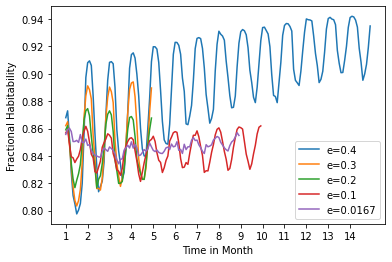

In [5]:

plt.plot(hab_frac_e04,label='e=0.4')
plt.plot(hab_frac_e03,label='e=0.3')
plt.plot(hab_frac_e02,label='e=0.2')
plt.plot(hab_frac_e01,label='e=0.1')
plt.plot(hab_frac_e0,label='e=0.0167')
plt.legend()
plt.xticks(range(0,168,12),labels=['1','2','3','4','5','6','7','8','9','10','11','12','13','14'])

#plt.title('Scaled Grid Fraction for TS between 273 K and 373 K')
plt.ylabel('Fractional Habitability')
plt.xlabel('Time in Month')
plt.show()

In [6]:
len(np.array(HabFrac(TS_liquid_e04)).tolist())/12

14.0

In [7]:
TS_liquid_e04_N = TS_liquid_e04.where((TS_liquid_e04.lat > 0 ) & (TS_liquid_e04.lat < 90))
TS_liquid_e04_S = TS_liquid_e04.where((TS_liquid_e04.lat > -90 ) & (TS_liquid_e04.lat < 0))

TS_liquid_e03_N = TS_liquid_e03.where((TS_liquid_e03.lat > 0 ) & (TS_liquid_e03.lat < 90))
TS_liquid_e03_S = TS_liquid_e03.where((TS_liquid_e03.lat > -90 ) & (TS_liquid_e03.lat < 0))

TS_liquid_e02_N = TS_liquid_e02.where((TS_liquid_e02.lat > 0 ) & (TS_liquid_e02.lat < 90))
TS_liquid_e02_S = TS_liquid_e02.where((TS_liquid_e02.lat > -90 ) & (TS_liquid_e02.lat < 0))

TS_liquid_e01_N = TS_liquid_e01.where((TS_liquid_e01.lat > 0 ) & (TS_liquid_e01.lat < 90))
TS_liquid_e01_S = TS_liquid_e01.where((TS_liquid_e01.lat > -90 ) & (TS_liquid_e01.lat < 0))

TS_liquid_e0_N = TS_liquid_e0.where((TS_liquid_e0.lat > 0 ) & (TS_liquid_e0.lat < 90))
TS_liquid_e0_S = TS_liquid_e0.where((TS_liquid_e0.lat > -90 ) & (TS_liquid_e0.lat < 0))

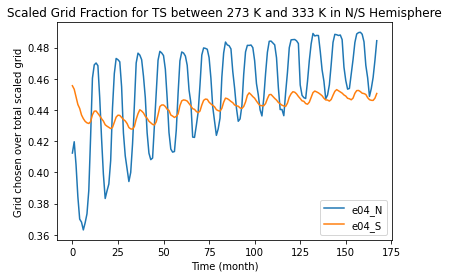

In [8]:
plt.plot(np.array(HabFrac(TS_liquid_e04_N)).tolist(),label='e04_N')
plt.plot(np.array(HabFrac(TS_liquid_e04_S)).tolist(),label='e04_S')


# plt.plot(np.array(HabFrac(TS_liquid_e03)).tolist(),label='e03')
# plt.plot(np.array(HabFrac(TS_liquid_e03)).tolist(),label='e03')
# plt.plot(np.array(HabFrac(TS_liquid_e02)).tolist(),label='e02')
# plt.plot(np.array(HabFrac(TS_liquid_e01_N)).tolist(),label='e01_N')
# plt.plot(np.array(HabFrac(TS_liquid_e01_S)).tolist(),label='e01_S')

# plt.plot(np.array(HabFrac(TS_liquid_e0)).tolist(),label='e0')
plt.legend()
plt.title('Scaled Grid Fraction for TS between 273 K and 333 K in N/S Hemisphere')
plt.ylabel('Grid chosen over total scaled grid')
plt.xlabel('Time (month)')
plt.show()

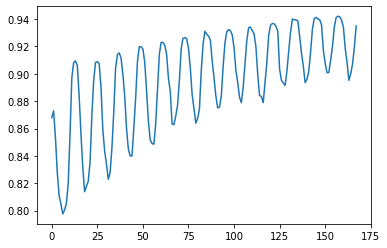

In [9]:
plt.plot(np.array(HabFrac(TS_liquid_e04)).tolist(),label='e04')

In [10]:
ds0 = xr.open_mfdataset('/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.e0_obl0_branch.001/atm/hist/*h0*.nc')
ds0

<xarray.Dataset>
Dimensions:                  (ilev: 71, lat: 96, lev: 70, lon: 144, nbnd: 2, time: 12, zlon: 1)
Coordinates:
  * lat                      (lat) float64 -90.0 -88.11 -86.21 ... 88.11 90.0
  * zlon                     (zlon) float64 0.0
  * lon                      (lon) float64 0.0 2.5 5.0 7.5 ... 352.5 355.0 357.5
  * lev                      (lev) float64 5.96e-06 9.827e-06 ... 976.3 992.6
  * ilev                     (ilev) float64 4.5e-06 7.42e-06 ... 985.1 1e+03
  * time                     (time) object 0008-04-01 00:00:00 ... 0009-03-01...
Dimensions without coordinates: nbnd
Data variables: (12/253)
    zlon_bnds                (time, zlon, nbnd) float64 dask.array<chunksize=(1, 1, 2), meta=np.ndarray>
    gw                       (time, lat) float64 dask.array<chunksize=(1, 96), meta=np.ndarray>
    hyam                     (time, lev) float64 dask.array<chunksize=(1, 70), meta=np.ndarray>
    hybm                     (time, lev) float64 dask.array<chunksize=(1, 70), meta=np.ndarray>
    P0                       (time) float64 1e+05 1e+05 1e+05 ... 1e+05 1e+05
    hyai                     (time, ilev) float64 dask.array<chunksize=(1, 71), meta=np.ndarray>
    ...                       ...
    jh2o_a                   (time, lev, lat, lon) float32 dask.array<chunksize=(1, 70, 96, 144), meta=np.ndarray>
    jh2o_b                   (time, lev, lat, lon) float32 dask.array<chunksize=(1, 70, 96, 144), meta=np.ndarray>
    jh2o_c                   (time, lev, lat, lon) float32 dask.array<chunksize=(1, 70, 96, 144), meta=np.ndarray>
    r_O1D_H2O                (time, lev, lat, lon) float32 dask.array<chunksize=(1, 70, 96, 144), meta=np.ndarray>
    wet_deposition_NHx_as_N  (time, lat, lon) float32 dask.array<chunksize=(1, 96, 144), meta=np.ndarray>
    wet_deposition_NOy_as_N  (time, lat, lon) float32 dask.array<chunksize=(1, 96, 144), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              b.e21.BWma1850.f19_g17.e0_obl0_branch.001
    logname:           pybl
    host:              d10s8b4.arc4.lee
    initial_file:      /nobackup/phydrm/cesm2_inputdata//cesm2_init/b.e20.BWm...
    topography_file:   /nobackup/phydrm/cesm2_inputdata//atm/cam/topo/fv_1.9x...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  month_1

In [11]:
ds0.AREA

<xarray.DataArray 'AREA' (time: 12, lat: 96, lon: 144)>
dask.array<concatenate, shape=(12, 96, 144), dtype=float32, chunksize=(1, 96, 144), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -90.0 -88.11 -86.21 -84.32 ... 84.32 86.21 88.11 90.0
  * lon      (lon) float64 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) object 0008-04-01 00:00:00 ... 0009-03-01 00:00:00
Attributes:
    units:         m2
    long_name:     area of grid box
    cell_methods:  time: mean

In [12]:
# check if total area from grid = total area from 4pir^2
r=6371*10**3

(ds0.AREA.isel(time=0).values.sum())/(r**2*4*np.pi)

1.0000690850814835

In [13]:
# check if habitable fraction from 'AREA' is the same as scaled grid

test1=ds0.AREA.isel(time=0).where((ds0.isel(time=0).TS.lat > 0 ) & (ds0.isel(time=0).TS.lat < 90)).values

AREA_result=np.nansum(test1)/(ds0.AREA.isel(time=0).values.sum())

print('AREA_result is',AREA_result)

#
test2=ds0.AREA.isel(time=1).where((ds0.isel(time=1).TS.lat > 0 ) & (ds0.isel(time=1).TS.lat < 90)).values

AREA_result_2=np.nansum(test1)/(ds0.AREA.isel(time=1).values.sum())

print('AREA_result2 is',AREA_result_2)


#
scaled_ds=ds0.TS.where((ds0.TS.lat > 0 ) & (ds0.TS.lat < 90))

scaled_grid_result=HabFrac(scaled_ds)

print('scaled grid calculation is',np.array(scaled_grid_result).tolist())



AREA_result is 0.49993166
AREA_result2 is 0.49993166
scaled grid calculation is [0.49993165249623445, 0.49993165249623445, 0.49993165249623445, 0.49993165249623445, 0.49993165249623445, 0.49993165249623445, 0.49993165249623445, 0.49993165249623445, 0.49993165249623445, 0.49993165249623445, 0.49993165249623445, 0.49993165249623445]


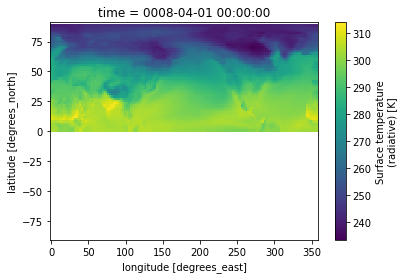

In [14]:
def HabFrac_test(DS):
    
    Habfrac=[]
    
    for i in range(len(DS.time)):
        Habfrac.append(np.sum(np.logical_not(np.isnan(DS.isel(time=i))).astype(int)
                              *weight_factor2)/total_scaled_grid)
    
    return Habfrac

ds0.TS.isel(time=0).where((ds0.isel(time=0).TS.lat > 0 ) & (ds0.isel(time=0).TS.lat < 90)).plot()

In [15]:
File_h0 = "/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.e0_obl0.001/atm/hist/b.e21.BWma1850.f19_g17.e0_obl0.001.cam.h0.0001-03.nc" #file name

DataSet_h0 = xr.open_dataset(File_h0) #open the file

gw = DataSet_h0.gw.values

Pressure = DataSet_h0.lev.values

gw = DataSet_h0.gw.values

#%% define latitudinal weighting function

def LatWeightAnyVar(DS, time = False):
    try:
        DS = DS.mean(dim='lon')#take longitudinal mean
    except:
        print('')
    if (time == False):
        try:
            DS = DS.mean(dim='time')#take time mean
        except:
            print('')
    DS = gw*DS #multiply by gaussian weights
    try:
        DS = np.sum(DS,axis=1)/gw.sum() #weighted mean
    except:
        DS = np.sum(DS,axis=0)/gw.sum() #weighted mean 
    return DS #return a numpy array that has been modified above

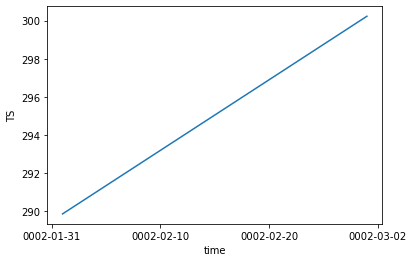

In [16]:
LatWeightAnyVar(TS_obl0[4].TS[10:12,:,:], time = True).plot()

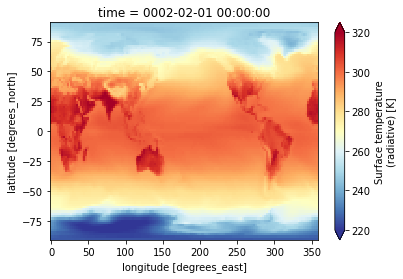

In [17]:
TS_obl0[4].TS[10,:,:].plot.imshow(cmap='RdYlBu_r',vmin=220,vmax=320)

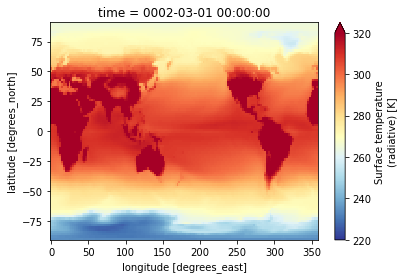

In [18]:
TS_obl0[4].TS[11,:,:].plot.imshow(cmap='RdYlBu_r',vmin=220,vmax=320)